## Import libraries

In [66]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import joblib

In [67]:
import os

SAVE_DIR = "../assets/diagrams"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Save folder:", SAVE_DIR)

Save folder: ../assets/diagrams


## Load Dataset

In [68]:
data = pd.read_csv("vehicle_maintenance_data.csv")

data.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977482,Good,Good,Weak,1


## Check columns

In [69]:
data.columns

Index(['Vehicle_Model', 'Mileage', 'Maintenance_History', 'Reported_Issues',
       'Vehicle_Age', 'Fuel_Type', 'Transmission_Type', 'Engine_Size',
       'Odometer_Reading', 'Last_Service_Date', 'Warranty_Expiry_Date',
       'Owner_Type', 'Insurance_Premium', 'Service_History',
       'Accident_History', 'Fuel_Efficiency', 'Tire_Condition',
       'Brake_Condition', 'Battery_Status', 'Need_Maintenance'],
      dtype='object')

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_Model         50000 non-null  object 
 1   Mileage               50000 non-null  int64  
 2   Maintenance_History   50000 non-null  object 
 3   Reported_Issues       50000 non-null  int64  
 4   Vehicle_Age           50000 non-null  int64  
 5   Fuel_Type             50000 non-null  object 
 6   Transmission_Type     50000 non-null  object 
 7   Engine_Size           50000 non-null  int64  
 8   Odometer_Reading      50000 non-null  int64  
 9   Last_Service_Date     50000 non-null  object 
 10  Warranty_Expiry_Date  50000 non-null  object 
 11  Owner_Type            50000 non-null  object 
 12  Insurance_Premium     50000 non-null  int64  
 13  Service_History       50000 non-null  int64  
 14  Accident_History      50000 non-null  int64  
 15  Fuel_Efficiency    

In [71]:
data.head(10)

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977482,Good,Good,Weak,1
5,Truck,31653,Average,2,1,Diesel,Automatic,800,70954,2023-08-12,2024-09-05,Third,16813,5,3,15.954422,Worn Out,Good,New,0
6,Motorcycle,51211,Average,2,8,Diesel,Automatic,2500,145563,2024-01-13,2025-07-20,Second,21057,10,0,16.455703,New,Good,New,0
7,Van,79093,Poor,2,2,Petrol,Automatic,2000,132354,2023-05-12,2026-02-13,First,6498,3,1,12.128404,Good,New,New,1
8,SUV,59673,Good,2,6,Electric,Manual,800,85733,2023-04-07,2025-04-21,First,12787,9,1,11.558027,Worn Out,Good,Weak,1
9,Bus,37001,Good,2,9,Diesel,Automatic,1500,8554,2023-08-05,2025-05-14,Third,20860,9,1,12.787248,Worn Out,New,New,0


## Preprocessing

In [72]:
target = "Need_Maintenance"

X = data.drop(target, axis=1)
y = data[target]

X.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977482,Good,Good,Weak


## Encode categorical columns

In [73]:
## Check categorical columns

In [74]:
X.select_dtypes(include=["object"]).columns

Index(['Vehicle_Model', 'Maintenance_History', 'Fuel_Type',
       'Transmission_Type', 'Last_Service_Date', 'Warranty_Expiry_Date',
       'Owner_Type', 'Tire_Condition', 'Brake_Condition', 'Battery_Status'],
      dtype='object')

In [75]:
## Encode all categorical columns

In [76]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column].astype(str))
    label_encoders[column] = le

X.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status
0,4,58765,1,0,4,1,0,2000,28524,238,422,1,20782,6,3,13.622204,1,1,2
1,5,60353,0,1,7,1,0,2500,133630,175,402,1,23489,7,0,13.625307,1,1,2
2,0,68072,2,0,2,1,0,1500,34022,89,364,0,17979,7,0,14.306302,1,0,2
3,0,60849,0,4,5,2,0,2500,81636,147,556,1,6220,7,3,18.709467,1,2,1
4,0,45742,2,5,1,2,1,2000,97162,56,504,2,16446,6,2,16.977482,0,0,2


In [77]:
## Check if everything is numeric

In [78]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_Model         50000 non-null  int64  
 1   Mileage               50000 non-null  int64  
 2   Maintenance_History   50000 non-null  int64  
 3   Reported_Issues       50000 non-null  int64  
 4   Vehicle_Age           50000 non-null  int64  
 5   Fuel_Type             50000 non-null  int64  
 6   Transmission_Type     50000 non-null  int64  
 7   Engine_Size           50000 non-null  int64  
 8   Odometer_Reading      50000 non-null  int64  
 9   Last_Service_Date     50000 non-null  int64  
 10  Warranty_Expiry_Date  50000 non-null  int64  
 11  Owner_Type            50000 non-null  int64  
 12  Insurance_Premium     50000 non-null  int64  
 13  Service_History       50000 non-null  int64  
 14  Accident_History      50000 non-null  int64  
 15  Fuel_Efficiency    

## Train / Test split

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (40000, 19)
Test: (10000, 19)


## Train Logistic Regression

In [80]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Accuracy: 0.8549


C:\Users\jithm\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Train Decision Tree

In [81]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


## Train Random Forest

In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1915
           1       1.00      1.00      1.00      8085

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [83]:
## check confusion matrix

In [84]:
confusion_matrix(y_test, y_pred_rf)

array([[1915,    0],
       [   0, 8085]])

In [85]:
## Confusion matrix diagram for Random Forest

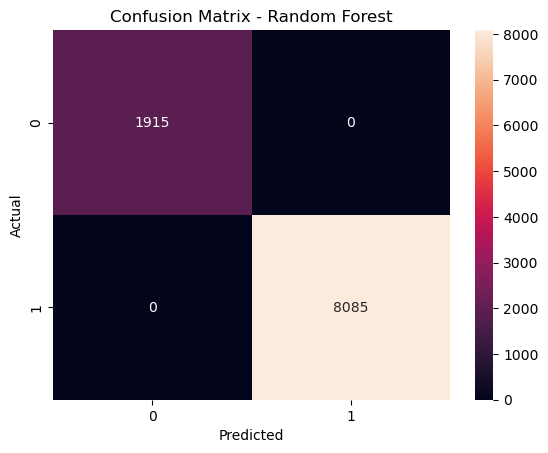

In [86]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os

SAVE_DIR = "../assets/diagrams"   # ✅ same as working one
os.makedirs(SAVE_DIR, exist_ok=True)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(f"{SAVE_DIR}/confusion_matrix.png")

plt.show()

In [87]:
## Feature importance chart

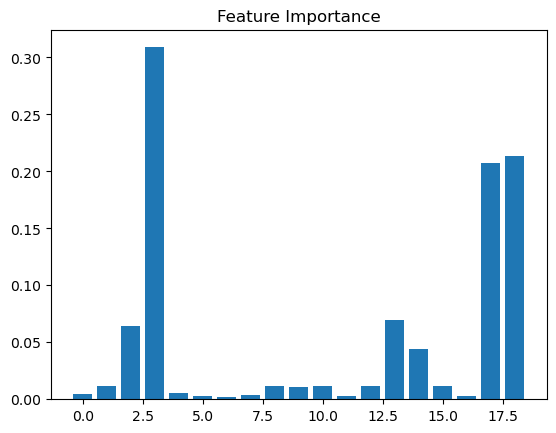

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import os

SAVE_DIR = "../assets/diagrams"
os.makedirs(SAVE_DIR, exist_ok=True)

importance = rf_model.feature_importances_

plt.figure()
plt.bar(range(len(importance)), importance)

plt.title("Feature Importance")

plt.savefig(f"{SAVE_DIR}/feature_importance.png")

plt.show()

In [89]:
## Actual vs Predicted Maintenance (Random Forest)

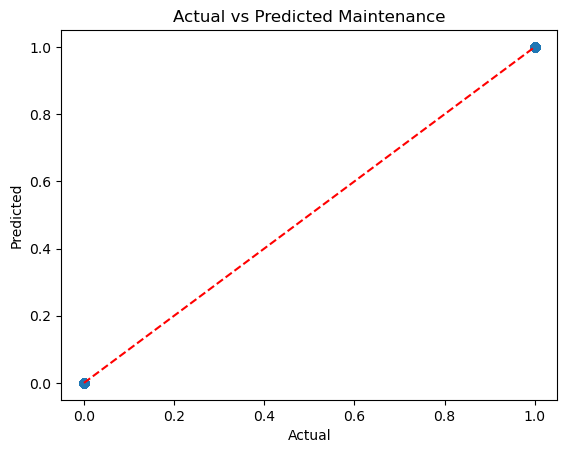

In [90]:
import matplotlib.pyplot as plt
import os

SAVE_DIR = "../assets/diagrams"
os.makedirs(SAVE_DIR, exist_ok=True)

plt.figure()

plt.scatter(y_test, y_pred_rf)
plt.plot([0, 1], [0, 1], color="red", linestyle="--")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Maintenance")

plt.savefig(f"{SAVE_DIR}/actual_vs_predicted.png")

plt.show()

## Compare all models

In [91]:
from sklearn.metrics import accuracy_score

acc_log = accuracy_score(y_test, y_pred_log)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(acc_log, acc_dt, acc_rf)

0.8549 1.0 1.0


## Accuracy comparison chart

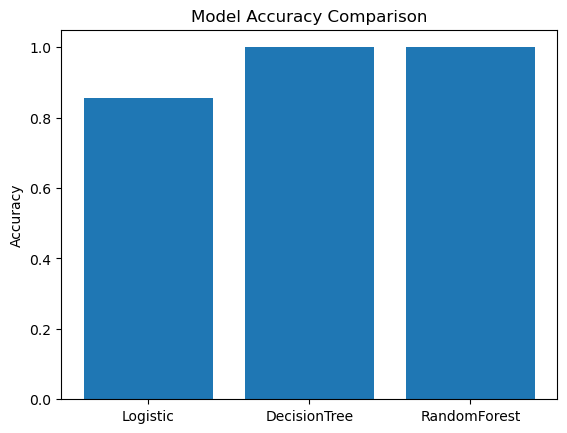

In [92]:
models = ["Logistic", "DecisionTree", "RandomForest"]
scores = [acc_log, acc_dt, acc_rf]

plt.figure()
plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.savefig(f"{SAVE_DIR}/model_accuracy.png")
plt.show()

## Save model

In [93]:
import joblib

joblib.dump(rf_model, "model.pkl")
joblib.dump(label_encoders, "encoders.pkl")

print("Model saved")

Model saved


In [94]:
## save workflow diagram

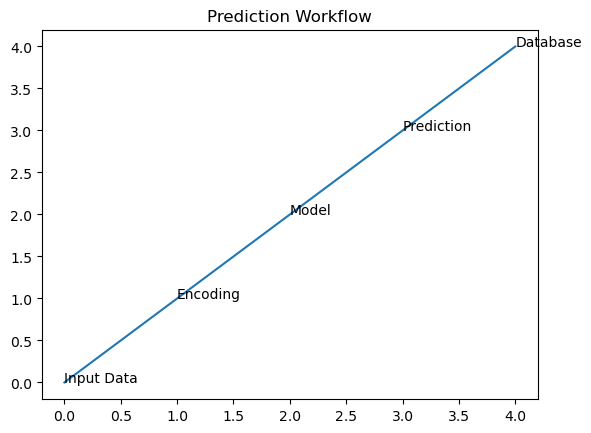

In [95]:
plt.figure()

labels = ["Input Data", "Encoding", "Model", "Prediction", "Database"]

y = range(len(labels))

plt.plot(y, y)

for i, txt in enumerate(labels):
    plt.text(i, i, txt)

plt.title("Prediction Workflow")

plt.savefig(f"{SAVE_DIR}/prediction_workflow.png")

plt.show()